# Results summary

The numbers the report is written from, read off the stored lane and product artefacts.
Nothing here runs an estimator and nothing here writes a file that ships: every figure the
report prints is produced by `scripts/07_figures.py`.

Metrics kept: **CE**, **SSIM**, **amplitude**, **CRPS**, **RCRV**. `rrmse` is still
computed and still selects the operating point, so it appears in the selection blocks
below, but it is not a reported number.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from paleoreco import paths
from paleoreco.assim import experiments as ex
from paleoreco.data import VARS

plt.rcParams["figure.dpi"] = 110

LANES = ["ppe", "trajectory", "withholding_random"]
# Directory name per lane, which is not the lane string inside metrics.csv: the
# withholding files carry the fold kind, the directory does not.
LANE_DIR = {"ppe": paths.LANE_PPE, "trajectory": paths.LANE_TRAJECTORY,
            "withholding_random": paths.LANE_WITHHOLDING}
CONFIG_NAME = {"ppe": "ppe_config.json", "trajectory": "trajectory_config.json",
               "withholding_random": "withholding_random_config.json"}
# Which treatment of observation staleness each lane is read at. The PPE lane reads every
# observation from the state being reconstructed, so there is no staleness to treat; the
# other two take the deflated treatment, which is the one the product carries. Reading
# each estimator at its lane's own treatment is what makes a row comparable across lanes.
LANE_TREATMENT = {"ppe": "off", "trajectory": "deflate", "withholding_random": "deflate"}

THREE = ex.ESTIMATOR_3DVAR
HG = ex.hgaoenkf_estimator("misfit")
HG_EV = ex.hgaoenkf_estimator("evidence")
HG_MT = ex.ESTIMATOR_HGAOENKF_MT
ROW_ORDER = [THREE, HG, HG_EV, HG_MT, "nearest", "idw"]

TAPER = ["localization_km", "shrinkage_lambda", "alpha"]
ANALOG = ["analog_k", "hybrid_w", "tendency_theta", "tendency_lag_yr", "redundancy_theta"]
CONFIG_COLS = TAPER + ANALOG
SKILL = ["ce", "ssim", "amplitude"]
CALIB = ["crps", "rcrv_bias", "rcrv_dispersion"]
# The withholding lane writes a row per fold and a row pooled over folds at fold = -1.
# The pooled row is the one to quote; averaging it with the per-fold rows shifts every
# withholding figure by enough to change a reported CE.
POOLED = -1

In [2]:
_SUFFIX = {"_temporal_add": "add", "_temporal_deflate": "deflate"}


def split_method(method):
    """A method label as (estimator, staleness treatment)."""
    for suffix, treatment in _SUFFIX.items():
        if method.endswith(suffix):
            return method[:-len(suffix)], treatment
    return method, "off"


def read_metrics(*roots):
    """Every metrics CSV under the given roots, with estimator and treatment split out."""
    frames = [pd.read_csv(p) for root in roots for p in sorted(Path(root).glob("*/*/metrics.csv"))]
    frames += [pd.read_csv(p) for root in roots for p in sorted(Path(root).glob("*/metrics.csv"))]
    if not frames:
        raise FileNotFoundError(f"no metrics.csv under {roots}; run the pipeline first")
    m = pd.concat(frames, ignore_index=True)
    m["model"], m["treatment"] = zip(*[split_method(x) for x in m.method])
    # The prior-free references depend on neither taper nor b_scale, so every runner
    # writes an identical copy.
    return m.drop_duplicates(
        subset=["model", "treatment", "lane", "split", "fold", "do_event", "channel",
                "metric", "b_scale"] + CONFIG_COLS, keep="first").reset_index(drop=True)


M = read_metrics(paths.RUNS, paths.ABLATIONS)
print(f"{len(M):,} rows | estimators {sorted(M.model.unique())}")
print(f"lanes {sorted(M.lane.unique())} | treatments {sorted(M.treatment.unique())}")

447,840 rows | estimators ['3dvar', '3dvar_sse', '3dvar_sse_rep', '3dvar_sse_rep_temporal', '3dvar_sse_temporal', 'hgaoenkf', 'hgaoenkf_correlation', 'hgaoenkf_correlation_perchan', 'hgaoenkf_evidence', 'hgaoenkf_evidence_loc12500', 'hgaoenkf_evidence_loc20000', 'hgaoenkf_evidence_loc5000', 'hgaoenkf_evidence_loc8000', 'hgaoenkf_evidence_locstatic', 'hgaoenkf_loc12500', 'hgaoenkf_loc20000', 'hgaoenkf_loc5000', 'hgaoenkf_loc8000', 'hgaoenkf_locstatic', 'hgaoenkf_mt', 'hgaoenkf_mt_1lag', 'hgaoenkf_mt_3lag', 'hgaoenkf_mt_7lag', 'hgaoenkf_mt_7lag_curv', 'idw', 'nearest']
lanes ['ppe', 'trajectory', 'withholding_random'] | treatments ['add', 'deflate', 'off']


## Selected operating point per (estimator, lane)

Read from each run's own `config.json` rather than re-derived, so the table says what the
analysis actually ran at.

In [3]:
def selected_config(estimator, lane):
    """The operating point a run selected, or None where that run does not exist."""
    p = paths.run_dir(estimator, LANE_DIR[lane]) / CONFIG_NAME[lane]
    if not p.exists():
        return None
    return json.load(open(p))["selected"]


BEST = {(est, lane): selected_config(est, lane)
        for est in ROW_ORDER for lane in LANES}
rows = []
for (est, lane), win in BEST.items():
    if win:
        rows.append({"estimator": est, "lane": lane, **win})
display(pd.DataFrame(rows).set_index(["estimator", "lane"]).round(4))

localization_km  shrinkage_lambda  \
estimator         lane                                                    
3dvar             ppe                         20000.0               0.0   
                  trajectory                  20000.0               0.0   
                  withholding_random              NaN               0.5   
hgaoenkf          ppe                             NaN               NaN   
                  trajectory                  20000.0               0.0   
                  withholding_random              NaN               NaN   
hgaoenkf_evidence ppe                             NaN               NaN   
                  trajectory                  20000.0               0.0   
                  withholding_random              NaN               NaN   
hgaoenkf_mt       ppe                             NaN               NaN   
                  trajectory                  20000.0               0.0   
                  withholding_random              NaN               NaN   

                                      alpha  b_scale  analog_k  hybrid_w  \
estimator         lane                                                     
3dvar             ppe                   0.5      1.0       NaN       NaN   
                  trajectory            0.5      0.1       NaN       NaN   
                  withholding_random    0.5      2.0       NaN       NaN   
hgaoenkf          ppe                   NaN      1.0      60.0       0.0   
                  trajectory            0.5      0.3       NaN       NaN   
                  withholding_random    NaN      1.0      60.0       0.0   
hgaoenkf_evidence ppe                   NaN      1.0     100.0       1.0   
                  trajectory            0.5      0.1       NaN       NaN   
                  withholding_random    NaN      2.0     100.0       1.0   
hgaoenkf_mt       ppe                   NaN      2.0     100.0       1.0   
                  trajectory            0.5      0.3       NaN       NaN   
                  withholding_random    NaN      2.0     100.0       1.0   

                                      tendency_theta  tendency_lag_yr  \
estimator         lane                                                  
3dvar             ppe                            NaN              NaN   
                  trajectory                     NaN              NaN   
                  withholding_random             NaN              NaN   
hgaoenkf          ppe                            0.0              0.0   
                  trajectory                     NaN              NaN   
                  withholding_random             0.0              0.0   
hgaoenkf_evidence ppe                            1.0            200.0   
                  trajectory                     NaN              NaN   
                  withholding_random             1.0            200.0   
hgaoenkf_mt       ppe                            2.0            400.0   
                  trajectory                     NaN              NaN   
                  withholding_random             2.0            400.0   

                                      redundancy_theta  
estimator         lane                                  
3dvar             ppe                              NaN  
                  trajectory                       NaN  
                  withholding_random               NaN  
hgaoenkf          ppe                              0.0  
                  trajectory                       NaN  
                  withholding_random               0.0  
hgaoenkf_evidence ppe                              0.0  
                  trajectory                       NaN  
                  withholding_random               0.0  
hgaoenkf_mt       ppe                              0.0  
                  trajectory                       NaN  
                  withholding_random               0.0

## Master summary

Each estimator at its own selected `b_scale`, on the disjoint test split, at the treatment
its lane is read under.

In [4]:
def at_operating_point(est, lane, channel="pooled"):
    """Test-split rows for one estimator on one lane, at its own selected point."""
    win = BEST.get((est, lane))
    sub = M[(M.model == est) & (M.lane == lane) & (M.split == "test")
            & (M.channel == channel) & (M.do_event == "all") & (M.fold == POOLED)]
    if est in ("nearest", "idw"):
        return sub[sub.treatment == "off"]
    if win is None or sub.empty:
        return sub.iloc[0:0]
    sub = sub[sub.treatment == LANE_TREATMENT[lane]]
    sub = sub[np.isclose(sub.b_scale, win["b_scale"])]
    for col in CONFIG_COLS:
        if col in win and col in sub.columns:
            keep = sub[col].isna() if pd.isna(win[col]) else np.isclose(sub[col].fillna(-999), win[col])
            sub = sub[keep]
    return sub


def summary_table(metrics, channel="pooled"):
    out = {}
    for est in ROW_ORDER:
        rec = {}
        for lane in LANES:
            sub = at_operating_point(est, lane, channel)
            for metric in metrics:
                v = sub[sub.metric == metric]["value"]
                if len(v):
                    rec[(lane, metric)] = float(v.iloc[0])
        if rec:
            out[est] = rec
    df = pd.DataFrame(out).T.reindex([e for e in ROW_ORDER if e in out])
    df.columns = pd.MultiIndex.from_tuples(df.columns)
    return df.round(4)


print("Skill:")
display(summary_table(SKILL))
print("Calibration:")
display(summary_table(CALIB))
for ch in VARS:
    print(ch)
    display(summary_table(SKILL, ch))

Skill:


ppe                   trajectory                    \
                       ce    ssim amplitude         ce    ssim amplitude   
3dvar              0.6515  0.6574    0.8047     0.5143  0.5792    0.6268   
hgaoenkf           0.6596  0.6655    0.8629     0.5399  0.6278    0.9140   
hgaoenkf_evidence  0.6769  0.6641    0.8197     0.5464  0.6260    0.7795   
hgaoenkf_mt        0.6941  0.6719    0.8202     0.5470  0.6272    0.8197   
nearest           -1.3668  0.1584    1.5335    -1.5027  0.1378    1.4694   
idw                0.1993  0.3312    0.5945     0.1051  0.3179    0.4967   

                  withholding_random            
                                  ce amplitude  
3dvar                         0.0854    0.3196  
hgaoenkf                      0.0819    0.3205  
hgaoenkf_evidence             0.0850    0.3139  
hgaoenkf_mt                   0.0810    0.3119  
nearest                      -0.4595    0.9428  
idw                          -0.0413    0.6381

Calibration:


ppe                           trajectory            \
                     crps rcrv_bias rcrv_dispersion       crps rcrv_bias   
3dvar              0.2899   -0.0146          1.2066     0.3769    0.3944   
hgaoenkf           0.3001    0.0154          2.0266     0.3628    0.5046   
hgaoenkf_evidence  0.2848   -0.0424          1.4428     0.3611    0.5307   
hgaoenkf_mt        0.2820    0.0175          1.6856     0.3587    0.5801   

                                  withholding_random                            
                  rcrv_dispersion               crps rcrv_bias rcrv_dispersion  
3dvar                      2.9680             1.0641   -0.0023          1.3883  
hgaoenkf                   3.2605             1.0707   -0.0058          1.5461  
hgaoenkf_evidence          3.2807             1.0665   -0.0031          1.4943  
hgaoenkf_mt                3.4452             1.0693   -0.0046          1.5150

mtco


ppe                   trajectory                    \
                       ce    ssim amplitude         ce    ssim amplitude   
3dvar              0.7285  0.7135    0.8774     0.6056  0.6569    0.6810   
hgaoenkf           0.7438  0.7292    0.9349     0.6357  0.7019    0.9800   
hgaoenkf_evidence  0.7490  0.7287    0.8892     0.6650  0.7034    0.8384   
hgaoenkf_mt        0.7474  0.7237    0.8903     0.6572  0.7027    0.8823   
nearest           -1.5748  0.1675    1.5574    -1.6137  0.1502    1.4720   
idw                0.1368  0.3371    0.5701     0.0676  0.3436    0.4776   

                  withholding_random            
                                  ce amplitude  
3dvar                         0.1098    0.3378  
hgaoenkf                      0.1086    0.3298  
hgaoenkf_evidence             0.1090    0.3293  
hgaoenkf_mt                   0.1074    0.3221  
nearest                      -0.3966    0.9534  
idw                           0.0147    0.6392

mtwa


ppe                   trajectory                    \
                       ce    ssim amplitude         ce    ssim amplitude   
3dvar              0.5490  0.6012    0.6961     0.3805  0.5015    0.5370   
hgaoenkf           0.5473  0.6018    0.7565     0.3996  0.5538    0.8073   
hgaoenkf_evidence  0.5809  0.5995    0.7169     0.3726  0.5486    0.6838   
hgaoenkf_mt        0.6231  0.6200    0.7162     0.3856  0.5516    0.7178   
nearest           -1.0898  0.1493    1.5009    -1.3401  0.1254    1.4662   
idw                0.2824  0.3253    0.6255     0.1600  0.2923    0.5227   

                  withholding_random            
                                  ce amplitude  
3dvar                         0.0283    0.2719  
hgaoenkf                      0.0192    0.2974  
hgaoenkf_evidence             0.0285    0.2747  
hgaoenkf_mt                   0.0190    0.2861  
nearest                      -0.6072    0.9168  
idw                          -0.1729    0.6346

## B-vs-R sweep

Test CE against `b_scale`, each estimator starred at its own selected point. A flat curve
means the lane is insensitive to the background-to-observation balance; a peak that sits
at the grid edge means the optimum is unbracketed and the number should not be quoted
without saying so.

This is also the evidence for the amplitude claim: where CE falls as `b_scale` rises while
the amplitude ratio climbs toward 1, a flatter reconstruction is the price of correct
shape rather than a tuning failure.

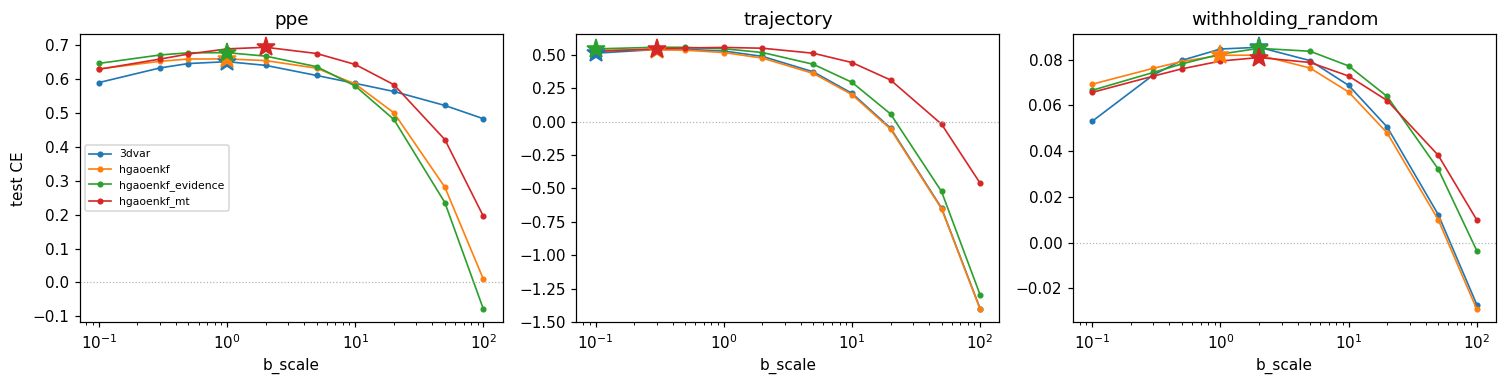

In [5]:
fig, axes = plt.subplots(1, len(LANES), figsize=(4.6 * len(LANES), 3.6), squeeze=False)
for ax, lane in zip(axes[0], LANES):
    for est in ROW_ORDER:
        if est in ("nearest", "idw"):
            continue
        sub = M[(M.model == est) & (M.lane == lane) & (M.split == "test")
                & (M.channel == "pooled") & (M.do_event == "all") & (M.fold == POOLED)
                & (M.metric == "ce") & (M.treatment == LANE_TREATMENT[lane])]
        if sub.empty:
            continue
        curve = sub.groupby("b_scale")["value"].max().sort_index()
        line, = ax.plot(curve.index, curve.values, marker="o", ms=3, lw=1.1, label=est)
        win = BEST.get((est, lane))
        if win is not None and win["b_scale"] in curve.index:
            ax.plot([win["b_scale"]], [curve.loc[win["b_scale"]]], marker="*", ms=13,
                    color=line.get_color(), zorder=5)
    ax.set_xscale("log")
    ax.set_title(lane)
    ax.set_xlabel("b_scale")
    ax.axhline(0.0, color="0.7", lw=0.8, ls=":")
axes[0][0].set_ylabel("test CE")
axes[0][0].legend(fontsize=7)
fig.tight_layout()

## The estimator ladder

One rung per mechanism, each a change to the rung below. The argument is that the untuned
mechanism carries most of the gain, so each rung is shown both at its own selected
`(k, hybrid_w)` and at fixed anchors, where only `b_scale` is re-selected. Matching the
anchor is what separates the mechanism from the retuning it allows.

- **R0** the published estimator: analogs ranked by R-weighted misfit.
- **R1** ranked by marginal likelihood instead, no tendency term.
- **R2** plus the single-lag tendency term at weight 1.
- **R3** plus the multiscale flow stack at weight 1, untuned.
- **R4** the same stack at the weight the grid selects.

In [6]:
LADDER = [
    ("R0  misfit rule", HG, {"tendency_theta": 0.0}),
    ("R1  + evidence rule", HG_EV, {"tendency_theta": 0.0}),
    ("R2  + 1-lag tendency, theta=1", HG_EV,
     {"tendency_theta": 1.0, "tendency_lag_yr": ex.MT_REFERENCE_LAG_YR}),
    ("R3  + flow stack, theta=1", HG_MT,
     {"tendency_theta": 1.0, "tendency_normalise": 1.0, "preserve_obs_trace": 1.0}),
    ("R4  + flow stack, tuned", HG_MT,
     {"tendency_normalise": 1.0, "preserve_obs_trace": 1.0}),
]
REPORT = ["rrmse", "ce", "amplitude"]


def rung_rows(lane, anchor=None):
    """Each rung at its own b_scale, selected on the selection split of this lane."""
    out = []
    for label, est, fixed in LADDER:
        q = M[(M.model == est) & (M.lane == lane) & (M.channel == "pooled")
              & (M.do_event == "all") & (M.fold == POOLED)
              & (M.treatment == LANE_TREATMENT[lane])].copy()
        for col, v in fixed.items():
            q = q[np.isclose(q[col].fillna(-999), v)]
        if anchor is not None:
            q = q[np.isclose(q.analog_k, anchor[0]) & np.isclose(q.hybrid_w, anchor[1])]
        sel = q[(q.split == "selection") & (q.metric == "rrmse")]
        if sel.empty:
            continue
        # The grid holds every axis but b_scale fixed within a rung, so the best
        # selection row names the configuration this rung is read at.
        key = sel.loc[sel["value"].idxmin(), ["analog_k", "hybrid_w", "b_scale"]]
        t = q[(q.split == "test") & np.isclose(q.analog_k, key.analog_k)
              & np.isclose(q.hybrid_w, key.hybrid_w) & np.isclose(q.b_scale, key.b_scale)]
        rec = {"rung": label, "k": int(key.analog_k), "w": key.hybrid_w,
               "b*": key.b_scale, "sel rrmse": round(float(sel["value"].min()), 4)}
        for metric in REPORT:
            v = t[t.metric == metric]["value"]
            rec[metric] = round(float(v.mean()), 4) if len(v) else np.nan
        out.append(rec)
    return pd.DataFrame(out).set_index("rung")


for lane in ("ppe", "trajectory"):
    print(f"--- {lane}: each rung at its own point ---")
    display(rung_rows(lane))

print("--- ppe: matched anchors, only b_scale re-selected ---")
for anchor in ((60, 1.0), (100, 1.0), (60, 0.25)):
    print(f"k={anchor[0]}, hybrid_w={anchor[1]}")
    display(rung_rows("ppe", anchor=anchor))

--- ppe: each rung at its own point ---


,k,w,b*,sel rrmse,rrmse,ce,amplitude
rung,,,,,,,
R0 misfit rule,60,0.00,1.0,0.5818,0.5835,0.6596,0.8629
R1 + evidence rule,60,0.75,1.0,0.5707,0.5754,0.6689,0.8087
"R2 + 1-lag tendency, theta=1",100,1.00,1.0,0.5656,0.5674,0.6781,0.8246
"R3 + flow stack, theta=1",100,1.00,2.0,0.5544,0.5570,0.6897,0.8217
"R4 + flow stack, tuned",100,1.00,2.0,0.5507,0.5551,0.6919,0.8209


--- trajectory: each rung at its own point ---


,k,w,b*,sel rrmse,rrmse,ce,amplitude
rung,,,,,,,
R0 misfit rule,60,0.0,0.1,0.7756,0.6822,0.5361,0.8900
"R4 + flow stack, tuned",100,1.0,0.5,0.7637,0.6694,0.5533,0.8442


--- ppe: matched anchors, only b_scale re-selected ---
k=60, hybrid_w=1.0


,k,w,b*,sel rrmse,rrmse,ce,amplitude
rung,,,,,,,
R0 misfit rule,60,1.0,2.0,0.6213,0.6240,0.6107,0.8581
R1 + evidence rule,60,1.0,1.0,0.5718,0.5777,0.6663,0.8022
"R2 + 1-lag tendency, theta=1",60,1.0,1.0,0.5660,0.5680,0.6773,0.8304
"R3 + flow stack, theta=1",60,1.0,2.0,0.5571,0.5601,0.6863,0.8223
"R4 + flow stack, tuned",60,1.0,2.0,0.5538,0.5585,0.6880,0.8217


k=100, hybrid_w=1.0


,k,w,b*,sel rrmse,rrmse,ce,amplitude
rung,,,,,,,
R0 misfit rule,100,1.0,2.0,0.6146,0.6144,0.6226,0.8468
R1 + evidence rule,100,1.0,1.0,0.5740,0.5783,0.6655,0.7989
"R2 + 1-lag tendency, theta=1",100,1.0,1.0,0.5656,0.5674,0.6781,0.8246
"R3 + flow stack, theta=1",100,1.0,2.0,0.5544,0.5570,0.6897,0.8217
"R4 + flow stack, tuned",100,1.0,2.0,0.5507,0.5551,0.6919,0.8209


k=60, hybrid_w=0.25


,k,w,b*,sel rrmse,rrmse,ce,amplitude
rung,,,,,,,
R0 misfit rule,60,0.25,1.0,0.5820,0.5836,0.6594,0.8476
R1 + evidence rule,60,0.25,1.0,0.5817,0.5841,0.6588,0.8308
"R2 + 1-lag tendency, theta=1",60,0.25,0.5,0.5821,0.5842,0.6588,0.8099
"R3 + flow stack, theta=1",60,0.25,1.0,0.5815,0.5833,0.6598,0.8304
"R4 + flow stack, tuned",60,0.25,1.0,0.5807,0.5829,0.6602,0.8301


## How much the choice of timescales matters

The flow stack is held as the definition of the estimator rather than tuned, so this
measures what holding it costs: one difference, three, seven, and seven plus curvature,
every entry at the same operating point and the same observation-space trace.

In [7]:
stack_dir = paths.ablation_dir("mt_stack")
if (stack_dir / "metrics.csv").exists():
    s = pd.read_csv(stack_dir / "metrics.csv")
    s["model"], s["treatment"] = zip(*[split_method(x) for x in s.method])
    s = s[(s.lane == "ppe") & (s.split == "test") & (s.channel == "pooled")
          & (s.do_event == "all") & (s.metric.isin(REPORT))]
    sel = pd.read_csv(stack_dir / "metrics.csv")
    sel["model"], _ = zip(*[split_method(x) for x in sel.method])
    sel = sel[(sel.split == "selection") & (sel.channel == "pooled")
              & (sel.do_event == "all") & (sel.metric == "rrmse")]
    best_b = sel.groupby("model").apply(
        lambda g: g.loc[g["value"].idxmin(), "b_scale"], include_groups=False)
    rows = []
    for model, b in best_b.items():
        t = s[(s.model == model) & np.isclose(s.b_scale, b)]
        rows.append({"stack": model.replace(f"{HG_MT}_", ""), "b*": b,
                     **{m: round(float(t[t.metric == m]["value"].mean()), 4) for m in REPORT}})
    display(pd.DataFrame(rows).set_index("stack"))
else:
    print(f"no stack sweep at {stack_dir}")

,b*,rrmse,ce,amplitude
stack,,,,
1lag,2.0,0.5632,0.6828,0.8260
3lag,2.0,0.5584,0.6882,0.8220
7lag,2.0,0.5552,0.6918,0.8206
7lag_curv,2.0,0.5531,0.6941,0.8202


## The analog covariance's own lengthscale

Sun et al. (2024) Table 2 give the flow-dependent covariance a lengthscale separate from
the static one, tighter as the ensemble shrinks. `static` is the shipped choice: the two
covariances tapered identically. The sweep selects nothing; it says what departing from
that would cost.

In [8]:
taper_dirs = [paths.ablation_dir(f"analog_taper_{rule}") for rule in ("misfit", "evidence")]
frames = [pd.read_csv(d / "metrics.csv") for d in taper_dirs if (d / "metrics.csv").exists()]
if frames:
    t = pd.concat(frames, ignore_index=True)
    t["model"], _ = zip(*[split_method(x) for x in t.method])
    sel = t[(t.split == "selection") & (t.channel == "pooled") & (t.do_event == "all")
            & (t.metric == "rrmse")]
    best = sel.groupby("model")["value"].min().sort_values()
    base = {m: v for m, v in best.items() if m.endswith("locstatic")}
    rows = []
    for model, v in best.items():
        rule = model.rsplit("_loc", 1)[0]
        ref = base.get(f"{rule}_locstatic", np.nan)
        rows.append({"estimator": model, "sel rrmse": round(float(v), 4),
                     "vs static %": round(100 * (v / ref - 1), 2) if ref == ref else np.nan})
    display(pd.DataFrame(rows).set_index("estimator"))
else:
    print(f"no analog taper sweep at {[str(d) for d in taper_dirs]}")

,sel rrmse,vs static %
estimator,,
hgaoenkf_evidence_loc12500,0.5611,-0.74
hgaoenkf_evidence_loc20000,0.5652,0.00
hgaoenkf_evidence_locstatic,0.5652,0.00
hgaoenkf_evidence_loc8000,0.5669,0.29
hgaoenkf_loc12500,0.5818,0.00
hgaoenkf_loc20000,0.5818,0.00
hgaoenkf_loc5000,0.5818,0.00
hgaoenkf_loc8000,0.5818,0.00
hgaoenkf_locstatic,0.5818,0.00


## Skill by timescale

The other two lanes grade one snapshot at a time, so a single number there mixes every
timescale together. A low-pass is cumulative and reads high wherever the slow components
carry the variance; a band subtracts one low-pass from another and is the honest
per-timescale view. Both are shown; the bands are what the claim should rest on.

In [9]:
def timescale_table(metric_prefix, names, estimators=None):
    estimators = estimators or [THREE, HG, HG_EV, HG_MT]
    out = {}
    for est in estimators:
        sub = at_operating_point(est, "trajectory")
        rec = {}
        for name in names:
            v = sub[sub.metric == f"{metric_prefix}_{name}"]["value"]
            if len(v):
                rec[name] = round(float(v.iloc[0]), 4)
        if rec:
            out[est] = rec
    return pd.DataFrame(out).T


LP = [f"lp{w}" for w in ex.LOWPASS_WINDOWS]
BP = [f"bp{a}_{b}" for a, b in ex.BANDS]
for prefix, label in (("corr", "correlation"), ("ce", "CE"), ("amp", "amplitude")):
    print(f"{label}, low-pass (cumulative):")
    display(timescale_table(prefix, LP))
    print(f"{label}, band-pass (per timescale):")
    display(timescale_table(prefix, BP))

correlation, low-pass (cumulative):


,lp25,lp100,lp250,lp500,lp1000,lp2000
3dvar,0.7114,0.7871,0.8070,0.8075,0.7910,0.8471
hgaoenkf,0.7552,0.8401,0.8692,0.8792,0.8793,0.9223
hgaoenkf_evidence,0.7481,0.8415,0.8739,0.8839,0.8859,0.9266
hgaoenkf_mt,0.7474,0.8428,0.8780,0.8910,0.8943,0.9315


correlation, band-pass (per timescale):


,bp25_100,bp100_250,bp250_500,bp500_1000,bp1000_2000
3dvar,0.0457,0.1382,0.5378,0.8144,0.9006
hgaoenkf,0.0451,0.1265,0.4631,0.7740,0.8949
hgaoenkf_evidence,0.0421,0.1082,0.4632,0.7936,0.9091
hgaoenkf_mt,0.0487,0.1155,0.4549,0.7883,0.9098


CE, low-pass (cumulative):


...

,bp25_100,bp100_250,bp250_500,bp500_1000,bp1000_2000
3dvar,-0.0763,-0.0104,0.2266,0.5639,0.7074
hgaoenkf,-0.5589,-0.2565,0.0657,0.5143,0.6920
hgaoenkf_evidence,-0.3018,-0.1539,0.1552,0.5872,0.7715
hgaoenkf_mt,-0.3849,-0.2089,0.1247,0.5715,0.7683


amplitude, low-pass (cumulative):


,lp25,lp100,lp250,lp500,lp1000,lp2000
3dvar,0.4298,0.4466,0.4525,0.4509,0.4144,0.3298
hgaoenkf,0.9085,0.9236,0.9317,0.9462,0.9443,0.8190
hgaoenkf_evidence,0.7329,0.7381,0.7448,0.7511,0.7374,0.6620
hgaoenkf_mt,0.7630,0.7649,0.7735,0.7807,0.7692,0.7053


amplitude, band-pass (per timescale):


,bp25_100,bp100_250,bp250_500,bp500_1000,bp1000_2000
3dvar,0.3423,0.3314,0.3975,0.5705,0.6561
hgaoenkf,0.8140,0.7528,0.7823,0.8997,1.0460
hgaoenkf_evidence,0.6385,0.5793,0.6233,0.7459,0.8665
hgaoenkf_mt,0.7000,0.6289,0.6662,0.7841,0.8886


## Does correcting the observation operator in time help?

A sample is dated to a block, so it reports on a state some way off from the one it is
assimilated at. `off` leaves that alone, `add` charges it as extra observation error, and
`deflate` also undoes the attenuation a lagged state carries. Each variant is read at its
own selected `b_scale`, since inflating R moves the balance the analysis wants.

In [10]:
def staleness_ladder(est, lane="trajectory", metrics=("ce", "amplitude", "ssim")):
    cfg = paths.run_dir(est, LANE_DIR[lane]) / CONFIG_NAME[lane]
    if not cfg.exists():
        return pd.DataFrame()
    by_method = json.load(open(cfg)).get("selected_b_scale_by_method", {})
    rows = []
    for method, b in by_method.items():
        model, treatment = split_method(method)
        sub = M[(M.model == model) & (M.treatment == treatment) & (M.lane == lane)
                & (M.split == "test") & (M.channel == "pooled") & (M.do_event == "all")
                & (M.fold == POOLED) & np.isclose(M.b_scale, b)]
        rec = {"estimator": est, "treatment": treatment, "b*": b}
        for metric in metrics:
            v = sub[sub.metric == metric]["value"]
            rec[metric] = round(float(v.mean()), 4) if len(v) else np.nan
        rows.append(rec)
    return pd.DataFrame(rows)


display(pd.concat([staleness_ladder(e) for e in (THREE, HG, HG_EV, HG_MT)],
                  ignore_index=True).set_index(["estimator", "treatment"]))

b*      ce  amplitude    ssim
estimator         treatment                                
3dvar             off        0.1  0.4361     0.6167  0.5768
                  add        0.3  0.5205     0.6456  0.6165
                  deflate    0.3  0.5418     0.7648  0.6169
hgaoenkf          off        0.3  0.4246     0.7894  0.6159
                  add        0.3  0.5313     0.7754  0.6270
                  deflate    0.1  0.5361     0.8900  0.6139
hgaoenkf_evidence off        0.1  0.4637     0.6890  0.6147
                  add        0.3  0.5411     0.7070  0.6341
                  deflate    0.1  0.5464     0.7795  0.6260
hgaoenkf_mt       off        0.3  0.4700     0.6963  0.6169
                  add        0.5  0.5471     0.6981  0.6330
                  deflate    0.5  0.5533     0.8442  0.6321

### The same numbers as a time series

One cell of the reconstruction against its truth, raw and smoothed, to make the band
table concrete.

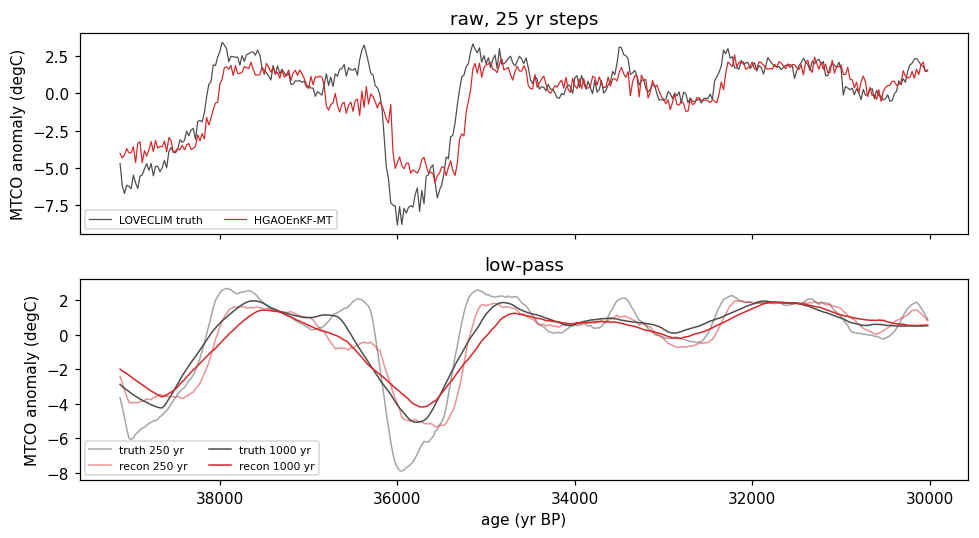

In [11]:
TRAJ = paths.run_dir(HG_MT, paths.LANE_TRAJECTORY) / "trajectory_analysis.npz"
if TRAJ.exists():
    from paleoreco.eval import da
    from paleoreco.assim.innovation import nearest_lat_index, nearest_lon_index

    z = np.load(TRAJ)
    step = float(z["step_yr"])
    # A Nordic Seas cell: high-latitude MTCO is where the D-O signal is largest.
    ci, la, lo = 0, 62.0, 3.0
    i = int(nearest_lat_index(np.array([la]), z["lats"])[0])
    j = int(nearest_lon_index(np.array([lo]), z["lons"])[0])
    truth = z["truth_anom"][:, ci, i, j].astype(float)
    recon = z["recon_realistic"][:, ci, i, j].astype(float)
    ages = z["ages"]

    fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
    axes[0].plot(ages, truth, lw=0.8, color="0.3", label="LOVECLIM truth")
    axes[0].plot(ages, recon, lw=0.8, color="C3", label="HGAOEnKF-MT")
    axes[0].set_title(f"raw, {step:.0f} yr steps")
    for w in (250, 1000):
        axes[1].plot(ages, da.lowpass_time(truth, w, step), lw=1.0, color="0.3",
                     alpha=0.5 if w == 250 else 1.0, label=f"truth {w} yr")
        axes[1].plot(ages, da.lowpass_time(recon, w, step), lw=1.0, color="C3",
                     alpha=0.5 if w == 250 else 1.0, label=f"recon {w} yr")
    axes[1].set_title("low-pass")
    for ax in axes:
        ax.legend(fontsize=7, ncol=2)
        ax.set_ylabel(f"{VARS[ci].upper()} anomaly (degC)")
    axes[1].set_xlabel("age (yr BP)")
    axes[1].invert_xaxis()
    fig.tight_layout()
else:
    print(f"no trajectory analysis at {TRAJ}")

## Skill against distance to the nearest observation

How far the reconstruction carries away from the proxies. Distance is per grid cell: the
great-circle km from that cell to the nearest assimilated site. `count` says which bins
hold enough cells to read.

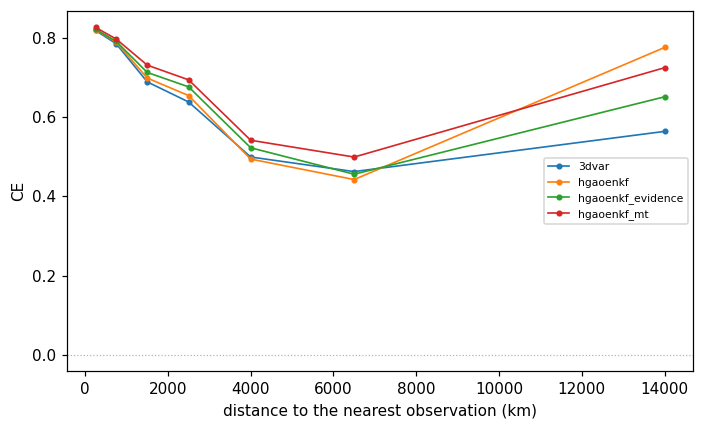

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 4.0))
for est in (THREE, HG, HG_EV, HG_MT):
    f = paths.run_dir(est, paths.LANE_PPE) / "ppe_skill_vs_distance.npz"
    if not f.exists():
        continue
    z = np.load(f)
    win = BEST.get((est, "ppe"))
    bi = int(np.argmin(np.abs(z["b_scales"] - win["b_scale"]))) if win else 0
    centres = 0.5 * (z["edges"][:-1] + z["edges"][1:])
    ax.plot(centres, z["ce"][bi], marker="o", ms=3, lw=1.1, label=est)
ax.axhline(0.0, color="0.7", lw=0.8, ls=":")
ax.set_xlabel("distance to the nearest observation (km)")
ax.set_ylabel("CE")
ax.legend(fontsize=7)
fig.tight_layout()

## Calibration

Skill says how wrong each estimator was; this says whether it knew.

- `crps` scores the whole predictive distribution in degC, so a confident-and-wrong
  forecast is punished harder than a vague one.
- `rcrv_dispersion` is the error divided by the predicted uncertainty: 1 is honest, above
  1 overconfident.
- `rcrv_bias` should be 0.

Against real proxies the predictive variance carries the proxy's own error and its
representativeness variance, because the residual holds all three.

In [13]:
print("Calibration at each estimator's own operating point, test split:")
display(summary_table(CALIB))
for ch in VARS:
    print(ch)
    display(summary_table(CALIB, ch))

Calibration at each estimator's own operating point, test split:


ppe                           trajectory            \
                     crps rcrv_bias rcrv_dispersion       crps rcrv_bias   
3dvar              0.2899   -0.0146          1.2066     0.3769    0.3944   
hgaoenkf           0.3001    0.0154          2.0266     0.3628    0.5046   
hgaoenkf_evidence  0.2848   -0.0424          1.4428     0.3611    0.5307   
hgaoenkf_mt        0.2820    0.0175          1.6856     0.3587    0.5801   

                                  withholding_random                            
                  rcrv_dispersion               crps rcrv_bias rcrv_dispersion  
3dvar                      2.9680             1.0641   -0.0023          1.3883  
hgaoenkf                   3.2605             1.0707   -0.0058          1.5461  
hgaoenkf_evidence          3.2807             1.0665   -0.0031          1.4943  
hgaoenkf_mt                3.4452             1.0693   -0.0046          1.5150

mtco


ppe                           trajectory            \
                     crps rcrv_bias rcrv_dispersion       crps rcrv_bias   
3dvar              0.2727   -0.0180          0.9498     0.3501    0.2707   
hgaoenkf           0.2705    0.0419          1.4246     0.3308    0.4383   
hgaoenkf_evidence  0.2623   -0.0149          1.0551     0.3177    0.4444   
hgaoenkf_mt        0.2659    0.0436          1.1610     0.3152    0.4288   

                                  withholding_random                            
                  rcrv_dispersion               crps rcrv_bias rcrv_dispersion  
3dvar                      2.4221             1.2789    0.0133          1.5522  
hgaoenkf                   2.4437             1.2898    0.0162          1.7400  
hgaoenkf_evidence          2.4659             1.2864    0.0193          1.6784  
hgaoenkf_mt                2.3074             1.2885    0.0261          1.6988

mtwa


ppe                           trajectory            \
                     crps rcrv_bias rcrv_dispersion       crps rcrv_bias   
3dvar              0.3072   -0.0112          1.4176     0.4038    0.5182   
hgaoenkf           0.3297   -0.0111          2.4867     0.3948    0.5709   
hgaoenkf_evidence  0.3073   -0.0700          1.7461     0.4045    0.6170   
hgaoenkf_mt        0.2981   -0.0086          2.0816     0.4022    0.7315   

                                  withholding_random                            
                  rcrv_dispersion               crps rcrv_bias rcrv_dispersion  
3dvar                      3.4236             0.8494   -0.0179          1.2022  
hgaoenkf                   3.9091             0.8516   -0.0278          1.3237  
hgaoenkf_evidence          3.9282             0.8465   -0.0256          1.2838  
hgaoenkf_mt                4.2859             0.8502   -0.0354          1.3048

## What the noise budget is made of

The four arms cross the two terms that inflate R beyond the proxy's stated error: the
representativeness variance, and the temporal term. Read the arms at one frozen `b_scale`
to isolate a term, and at each arm's own to see what would ship: re-selecting `b_scale`
absorbs part of an inflation, so a term can look free on skill and still change the
spread.

In [14]:
rep_dir = paths.ablation_dir("rep_var")
ARMS = ["sse", "sse_rep", "sse_temporal", "sse_rep_temporal"]
if (rep_dir / "metrics.csv").exists():
    a = pd.read_csv(rep_dir / "metrics.csv")
    a["model"], a["treatment"] = zip(*[split_method(x) for x in a.method])
    a = a[(a.split == "test") & (a.channel == "pooled") & (a.do_event == "all")
          & (a.fold == POOLED)]
    show = ["rrmse", "amplitude", "crps", "rcrv_bias", "rcrv_dispersion"]

    frozen = 1.0
    rows = []
    for arm in ARMS:
        model = f"{THREE}_{arm}"
        sub = a[(a.model == model) & np.isclose(a.b_scale, frozen)]
        if len(sub):
            rows.append({"arm": arm, "b_scale": frozen,
                         **{m: round(float(sub[sub.metric == m]["value"].mean()), 4)
                            for m in show}})
    print(f"At a frozen b_scale = {frozen}:")
    display(pd.DataFrame(rows).set_index("arm"))

    rows = []
    for arm in ARMS:
        model = f"{THREE}_{arm}"
        cfg = rep_dir / "withholding_random_config.json"
        sel = a[(a.model == model)]
        sel_rows = pd.read_csv(rep_dir / "metrics.csv")
        sel_rows["model"], _ = zip(*[split_method(x) for x in sel_rows.method])
        s = sel_rows[(sel_rows.model == model) & (sel_rows.split == "selection")
                     & (sel_rows.channel == "pooled") & (sel_rows.do_event == "all")
                     & (sel_rows.metric == "rrmse") & (sel_rows.fold == POOLED)]
        if s.empty:
            continue
        b = float(s.loc[s["value"].idxmin(), "b_scale"])
        sub = sel[np.isclose(sel.b_scale, b)]
        rows.append({"arm": arm, "b*": b,
                     **{m: round(float(sub[sub.metric == m]["value"].mean()), 4)
                        for m in show}})
    print("At each arm's own selected b_scale:")
    display(pd.DataFrame(rows).set_index("arm"))
else:
    print(f"no rep_var ablation at {rep_dir}")

At a frozen b_scale = 1.0:


,b_scale,rrmse,amplitude,crps,rcrv_bias,rcrv_dispersion
arm,,,,,,
sse,1.0,0.9613,0.2517,1.0734,0.0103,1.6116
sse_rep,1.0,0.9610,0.2368,1.0685,0.0040,1.4682
sse_temporal,1.0,0.9565,0.2967,1.0662,0.0028,1.5748
sse_rep_temporal,1.0,0.9567,0.2787,1.0625,-0.0014,1.4413


At each arm's own selected b_scale:


,b*,rrmse,amplitude,crps,rcrv_bias,rcrv_dispersion
arm,,,,,,
sse,1.0,0.9613,0.2517,1.0734,0.0103,1.6116
sse_rep,2.0,0.9607,0.2674,1.0703,0.0042,1.4230
sse_temporal,1.0,0.9565,0.2967,1.0662,0.0028,1.5748
sse_rep_temporal,2.0,0.9563,0.3196,1.0641,-0.0023,1.3883
